# Ejercicio Integrador 

### Modulo 2 Tema 2 Transformaciones de Datos para Modelos Predictivos



Con la base de datos que vieron en el modulo1 y que se encuentra en Github en la carpeta de Modulo 2 llamada carpeta_q1_2026_final.parquet, calcular para cada uno de los ramos de accidentes personales y Gastos médicos:



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

plt.style.use('ggplot')
sns.set_palette('viridis')

# Cargamos los datos en la variable 'base'
base = pd.read_parquet('cartera_q1_2026_final.parquet')
base.head()

# Usamos 'base' para filtrar 
ramos_interes = ['Accidentes Personales', 'GMM']
df_filtrado = base[base['ramo'].isin(ramos_interes)].copy()

print(f"--- Dataset Cargado ---")
print(f"Registros analizados: {len(df_filtrado)}")


--- Dataset Cargado ---
Registros analizados: 27738


### 1. Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)

In [2]:

def stats_actuariales(df_sub):

    n_polizas = len(df_sub)
    prima_total = df_sub['prima_total'].sum()
    prima_promedio = df_sub['prima_total'].mean()

    n_siniestros = df_sub['n_siniestros'].sum()
    monto_total = df_sub['monto_pagado'].sum()

    return pd.Series({
        'N Pólizas': n_polizas,
        'Prima Total': prima_total,
        'Prima Promedio': prima_promedio,
        'N Siniestros': n_siniestros,
        'Monto Pagado Total': monto_total,
        'Frecuencia': n_siniestros / n_polizas,
        'Severidad': monto_total / n_siniestros if n_siniestros > 0 else 0,
        'Siniestralidad': monto_total / prima_total if prima_total > 0 else 0
    })
# Paso extra: Limpiamos categorías para que SOLO salgan los 2 ramos de interés
df_filtrado = df_filtrado[df_filtrado['ramo'].isin(['Accidentes Personales', 'GMM'])].copy()
df_filtrado['ramo'] = df_filtrado['ramo'].astype(str) # Esto elimina las categorías "fantasma"


resumen_ramos = df_filtrado.groupby('ramo', observed=False).apply(stats_actuariales, include_groups=False).T
print(resumen_ramos.round(2))



ramo                Accidentes Personales           GMM
N Pólizas                         5207.00  2.253100e+04
Prima Total                   24980678.88  7.310223e+08
Prima Promedio                    4797.52  3.244518e+04
N Siniestros                      1833.00  8.146000e+03
Monto Pagado Total            22311397.14  9.691229e+07
Frecuencia                           0.35  3.600000e-01
Severidad                        12172.07  1.189692e+04
Siniestralidad                       0.89  1.300000e-01


### 2. Obtener las distribuciones de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. ¿Qué observas?


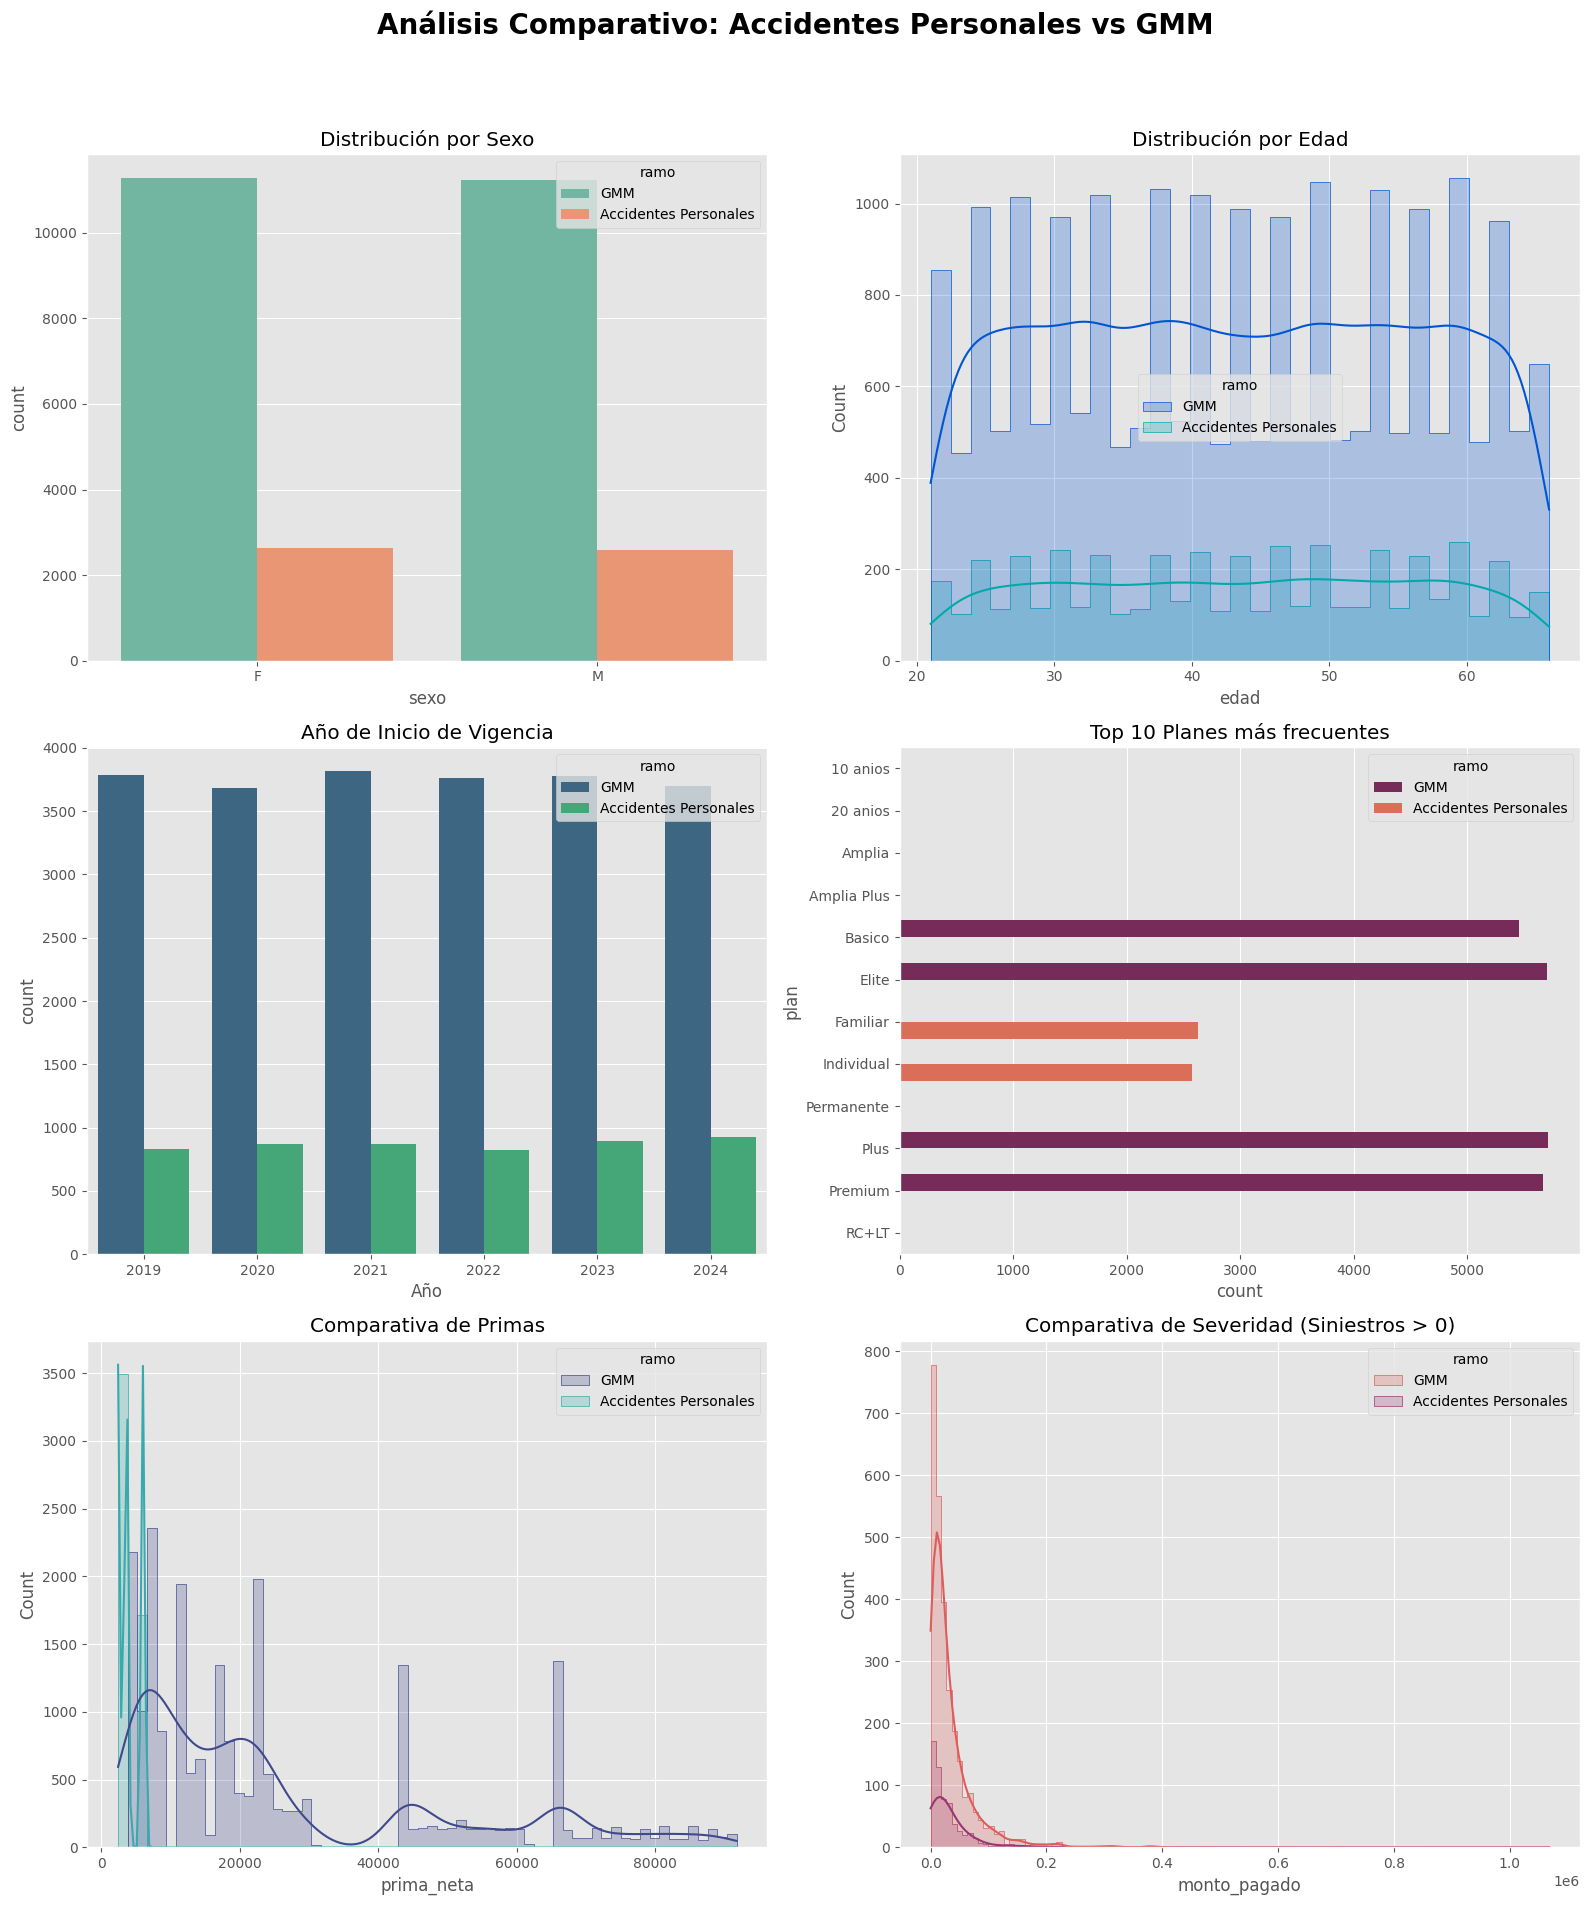

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
fig.suptitle('Análisis Comparativo: Accidentes Personales vs GMM', fontsize=20, fontweight='bold')

# Sexo por Ramo
sns.countplot(data=df_filtrado, x='sexo', hue='ramo',
              ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribución por Sexo')

# Edad por Ramo
sns.histplot(data=df_filtrado, x='edad', hue='ramo',
             kde=True, ax=axes[0, 1],
             palette='winter', element="step")
axes[0, 1].set_title('Distribución por Edad')

# Año de Inicio por Ramo
sns.countplot(data=df_filtrado, x='anio_poliza',
              hue='ramo', ax=axes[1, 0],
              palette='viridis')
axes[1, 0].set_title('Año de Inicio de Vigencia')
axes[1, 0].set_xlabel('Año')

# Plan por Ramo (Top 10)
top_planes = df_filtrado['plan'].value_counts().head(10).index
df_top_planes = df_filtrado[df_filtrado['plan'].isin(top_planes)]

sns.countplot(data=df_top_planes, y='plan',
              hue='ramo', ax=axes[1, 1],
              palette='rocket')
axes[1, 1].set_title('Top 10 Planes más frecuentes')

# Primas por Ramo
sns.histplot(data=df_filtrado, x='prima_neta',
             hue='ramo', kde=True,
             ax=axes[2, 0],
             palette='mako', element="step")
axes[2, 0].set_title('Comparativa de Primas')

# Siniestros por Ramo (Monto Pagado > 0)
df_sini = df_filtrado[df_filtrado['monto_pagado'] > 0]

sns.histplot(data=df_sini, x='monto_pagado',
             hue='ramo', kde=True,
             ax=axes[2, 1],
             palette='flare', element="step")
axes[2, 1].set_title('Comparativa de Severidad (Siniestros > 0)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Observaciones**

##### Distribución por sexo:
La distribución por sexo es prácticamente uniforme en ambos ramos. Tanto en GMM como en Accidentes Personales existe una cantidad muy similar de hombres y mujeres, por lo que no se observa un sesgo de género significativo en la cartera analizada.

##### Distribución por edad:
 La edad de los asegurados se distribuye de manera relativamente homogénea entre los 20 y 65 años para ambos ramos. Sin embargo, GMM presenta un volumen considerablemente mayor de asegurados en todos los rangos de edad, lo cual es consistente con el mayor tamaño de la cartera observada en las demás gráficas.

##### Año de inicio de vigencia:
El número de pólizas emitidas por año se mantiene bastante estable entre 2019 y 2024 para ambos productos. No se identifican tendencias claras de crecimiento o disminución, aunque GMM mantiene consistentemente un número de pólizas aproximadamente cuatro veces superior al de Accidentes Personales.

##### Planes más frecuentes:
Se observa una diferenciación clara entre los planes comercializados en cada ramo:

- En GMM predominan los planes Elite, Plus, Premium y Básico.
- En Accidentes Personales destacan principalmente los planes Familiar e Individual.

Esto sugiere que ambos productos están diseñados para segmentos de mercado distintos y poseen estructuras comerciales diferentes.

##### Comparativas de primas:
Las primas presentan una fuerte asimetría positiva en ambos ramos.

- En GMM las primas alcanzan valores mucho más elevados, llegando incluso a montos cercanos a los 90,000.
- En Accidentes Personales las primas se concentran en valores considerablemente más bajos y con menor dispersión.

Esto refleja que los seguros de Gastos Médicos Mayores implican una cobertura más amplia y, por tanto, un costo significativamente superior.

##### Comparativa de severidad de siniestros:
La distribución del monto pagado muestra una concentración importante de siniestros de bajo costo y una cola larga hacia valores altos, especialmente en GMM.

- La mayoría de los siniestros tienen montos relativamente pequeños.
- Existen pocos casos con pagos extremadamente elevados.
- GMM presenta una severidad mucho mayor que Accidentes Personales, con siniestros que alcanzan montos cercanos al millón de pesos.

### **Conclusión general**

El análisis muestra que Gastos Médicos Mayores (GMM) tiene una cartera más grande, primas más altas y siniestros potencialmente más severos que Accidentes Personales. Aunque ambos ramos presentan perfiles demográficos similares en términos de sexo y edad, difieren significativamente en la estructura de planes, el nivel de primas y el riesgo económico asociado a los siniestros. Estas diferencias son consistentes con la naturaleza de cada producto de seguro y sugieren que GMM requiere una gestión de riesgo más robusta debido a la alta severidad potencial de sus reclamaciones.

### 3. Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste

In [6]:

# Convertimos F en 0 y M en 1
df_filtrado['sexo_cod'] = df_filtrado['sexo'].map({'F': 0, 'M': 1})

# Esto creará una columna nueva por cada tipo de plan (0 o 1)
df_planes = pd.get_dummies(df_filtrado['plan'], prefix='plan', dtype=int)

# Unimos las nuevas columnas al dataframe original
df_preproc = pd.concat([df_filtrado, df_planes], axis=1)

print(f"Variable 'sexo' codificada como 'sexo_cod' (F:0, M:1)")
print(f"Variable 'plan' codificada mediante One-Hot Encoding. Nuevas columnas creadas: {len(df_planes.columns)}")

# Mostramos una vista previa de las nuevas columnas
cols_interes = ['sexo', 'sexo_cod', 'plan'] + list(df_planes.columns[:3]) # Mostramos solo los primeros 3 planes para no saturar
display(df_preproc[cols_interes].head())


Variable 'sexo' codificada como 'sexo_cod' (F:0, M:1)
Variable 'plan' codificada mediante One-Hot Encoding. Nuevas columnas creadas: 12


,sexo,sexo_cod,plan,plan_10 anios,plan_20 anios,plan_Amplia
2,M,1,Basico,0,0,0
6,M,1,Plus,0,0,0
7,M,1,Plus,0,0,0
8,M,1,Elite,0,0,0
10,F,0,Premium,0,0,0


### Explicación

Se codificaron las variables sexo y plan debido a que ambas son variables categóricas y los algoritmos de Machine Learning requieren que la información se encuentre en formato numérico para poder procesarla adecuadamente.

Para la variable sexo se aplicó una codificación binaria (Label Encoding), asignando el valor 0 a femenino (F) y 1 a masculino (M), ya que se trata de una variable con únicamente dos categorías.

Para la variable plan se utilizó la técnica de One-Hot Encoding, la cual consiste en crear una variable indicadora para cada categoría existente. Esta técnica fue seleccionada porque los diferentes planes no presentan un orden natural entre sí; por lo tanto, asignar valores numéricos consecutivos podría inducir relaciones artificiales que afectarían el desempeño e interpretación de los modelos.

La aplicación de estas técnicas de codificación permite transformar las variables categóricas a un formato adecuado para su uso en modelos estadísticos y de aprendizaje automático, conservando la información relevante contenida en cada variable.

### 4. Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Variables a escalar
vars_a_escalar = ['prima_neta', 'monto_pagado']

# Z-Score (StandardScaler)
scaler_z = StandardScaler()
z_scaled = scaler_z.fit_transform(df_preproc[vars_a_escalar])
df_preproc['prima_neta_zscore'] = z_scaled[:, 0]
df_preproc['monto_pagado_zscore'] = z_scaled[:, 1]

# Min-Max (MinMaxScaler)
scaler_mm = MinMaxScaler()
mm_scaled = scaler_mm.fit_transform(df_preproc[vars_a_escalar])
df_preproc['prima_neta_minmax'] = mm_scaled[:, 0]
df_preproc['monto_pagado_minmax'] = mm_scaled[:, 1]

# Robust Scaling (RobustScaler)
scaler_rb = RobustScaler()
rb_scaled = scaler_rb.fit_transform(df_preproc[vars_a_escalar])
df_preproc['prima_neta_robust'] = rb_scaled[:, 0]
df_preproc['monto_pagado_robust'] = rb_scaled[:, 1]


# Comparación de Estadísticas
cols_resumen = ['prima_neta', 'prima_neta_zscore', 'prima_neta_minmax', 'prima_neta_robust',
                'monto_pagado', 'monto_pagado_zscore', 'monto_pagado_minmax', 'monto_pagado_robust']

resumen_stats = df_preproc[cols_resumen].describe().round(3)
display(resumen_stats)




,prima_neta,prima_neta_zscore,prima_neta_minmax,prima_neta_robust,monto_pagado,monto_pagado_zscore,monto_pagado_minmax,monto_pagado_robust
count,27738.000,27738.000,27738.000,27738.000,27738.000,27738.000,27738.000,27738.000
mean,22586.389,0.000,0.226,0.451,4298.208,-0.000,0.004,4298.208
std,22946.919,1.000,0.257,1.078,21669.772,1.000,0.020,21669.772
min,2400.000,-0.880,0.000,-0.497,0.000,-0.198,0.000,0.000
25%,6000.000,-0.723,0.040,-0.328,0.000,-0.198,0.000,0.000
50%,12980.000,-0.419,0.118,0.000,0.000,-0.198,0.000,0.000
75%,27280.000,0.205,0.278,0.672,0.000,-0.198,0.000,0.000
max,91740.000,3.014,1.000,3.701,1067933.830,49.085,1.000,1067933.830


### **Conlusión**


Se aplicaron tres técnicas de escalamiento (Z-Score, Min-Max y Robust Scaling) a las variables prima_neta y monto_pagado con el objetivo de comparar su efecto sobre la distribución de los datos.

En el caso de StandardScaler (Z-Score), las variables quedaron centradas alrededor de cero y con desviación estándar cercana a uno. Sin embargo, los valores extremos siguen teniendo una influencia importante, especialmente en la variable monto_pagado, donde se observan valores estandarizados de hasta 49 desviaciones estándar sobre la media.

Con MinMaxScaler, los datos fueron transformados al intervalo [0,1]. Aunque facilita la comparación entre variables con diferentes escalas, los valores atípicos continúan afectando la distribución, concentrando gran parte de las observaciones cerca de cero.

Por su parte, RobustScaler utiliza la mediana y el rango intercuartílico para realizar la transformación, por lo que es menos sensible a valores extremos. Esto resulta especialmente útil para la variable monto_pagado, que presenta una fuerte asimetría y una gran cantidad de valores iguales a cero junto con algunos siniestros de muy alta severidad.

En conclusión, debido a la presencia de distribuciones altamente sesgadas y valores atípicos característicos de los datos de seguros, Robust Scaling parece ser el método más adecuado para estas variables, ya que reduce la influencia de observaciones extremas sin perder información relevante.

La variable monto_pagado presenta valores atípicos muy marcados, como se observa en el valor máximo estandarizado de 49.08 bajo Z-Score, lo que confirma la presencia de siniestros de alta severidad respecto al comportamiento promedio de la cartera.


### 5. Haz la transformación Box-Cox, logarítmica y Yeo-Johnson a la severidad. Haz un histograma de cada la serie original vs las transformaciones. Agrega la distribución normal.

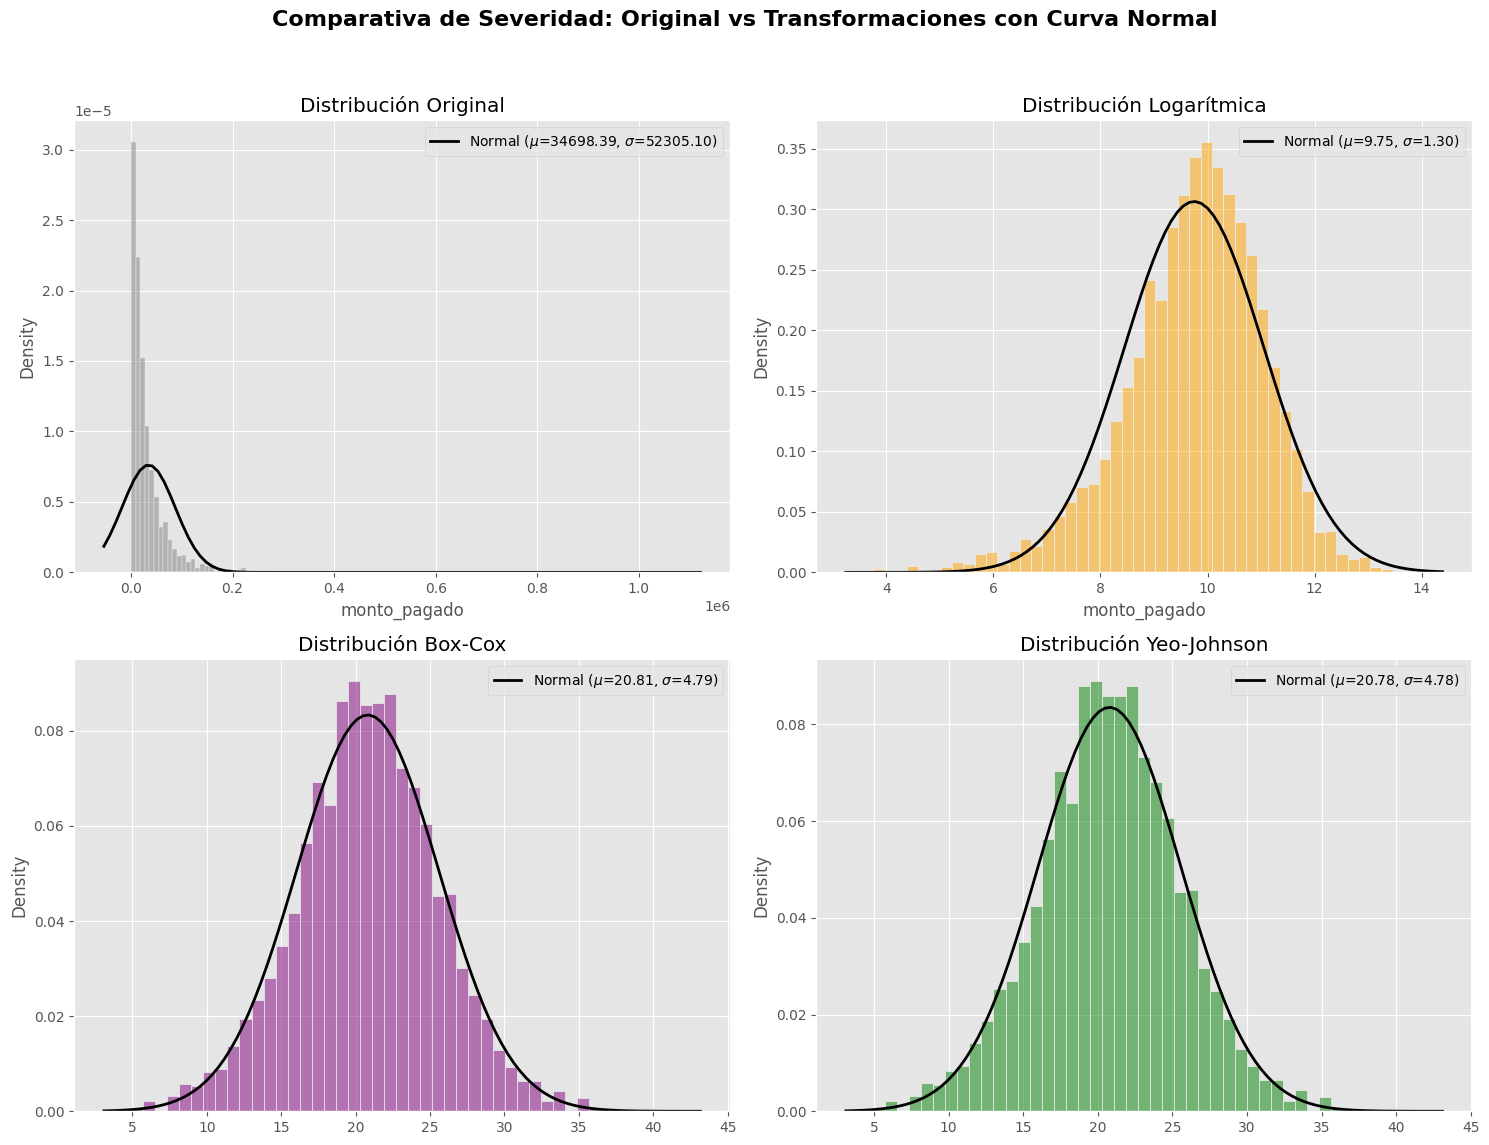

In [8]:

from scipy.stats import norm, lognorm

# Filtramos los siniestros para el análisis de severidad
df_sev = df_preproc[df_preproc['monto_pagado'] > 0].copy()

# Definimos las series a graficar
series = {
    'Original': df_sev['monto_pagado'],
    'Logarítmica': np.log(df_sev['monto_pagado']),
    'Box-Cox': stats.boxcox(df_sev['monto_pagado'])[0],
    'Yeo-Johnson': stats.yeojohnson(df_sev['monto_pagado'])[0]
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Comparativa de Severidad: Original vs Transformaciones con Curva Normal', fontsize=16, fontweight='bold')

axes = axes.flatten()
colores = ['gray', 'orange', 'purple', 'green']

for i, (nombre, data) in enumerate(series.items()):
    # Graficamos el Histograma en escala de densidad
    sns.histplot(data, kde=False, stat="density", ax=axes[i], color=colores[i], alpha=0.5)
    
    # Ajustamos una distribución normal teórica a los datos
    mu, std = norm.fit(data)
    
    # Creamos el eje X para la curva normal
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    
    # Dibujamos la curva normal sobre el histograma
    axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal ($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    axes[i].set_title(f'Distribución {nombre}')
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



 

Análisis para el reporte:

La variable de severidad original presenta una distribución altamente sesgada hacia la derecha, característica común en datos de seguros debido a la existencia de pocos siniestros de gran magnitud. Las tres transformaciones analizadas mejoran la aproximación a una distribución normal, siendo Box-Cox y Yeo-Johnson las que generan los mejores resultados. Ambas producen distribuciones prácticamente simétricas y con un ajuste muy cercano a la curva normal teórica. La transformación logarítmica también mejora considerablemente la distribución, aunque el ajuste es ligeramente inferior. Por lo tanto, para futuros modelos estadísticos o de Machine Learning que asuman normalidad o se beneficien de distribuciones más simétricas, Box-Cox y Yeo-Johnson serían las alternativas más adecuadas para transformar la variable de severidad.


### 6. Crea el Q-Q plot, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?

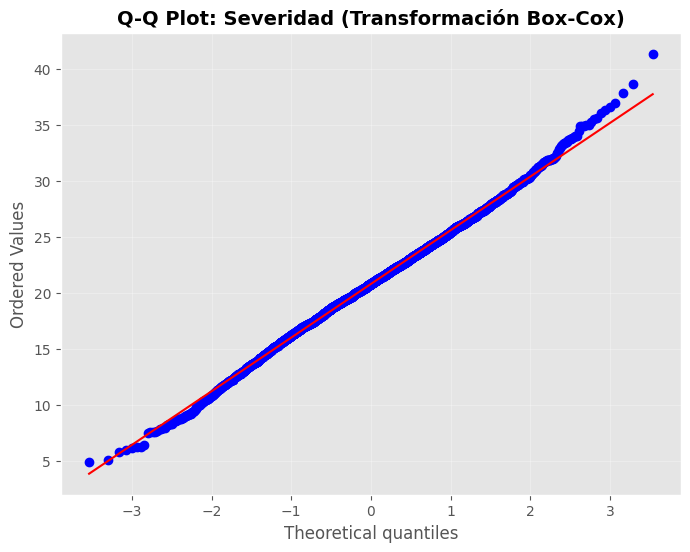

Estadístico de prueba: 13.3610
P-value: 0.0013


In [9]:

import scipy.stats as stats

# Usamos la severidad transformada con Box-Cox (la que mejor se veía en el paso anterior)
sev_bc = stats.boxcox(df_sev['monto_pagado'])[0]

# Creamos el Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(sev_bc, dist="norm", plot=plt)
plt.title('Q-Q Plot: Severidad (Transformación Box-Cox)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Aqui vamos a hacer la prueba de hipótesis de normalidad (D'Agostino-Pearson)
# H0: Los datos siguen una distribución normal
# H1: Los datos NO siguen una distribución normal
k2, p_value = stats.normaltest(sev_bc)

print(f"Estadístico de prueba: {k2:.4f}")
print(f"P-value: {p_value:.4f}")



### **Qué concluyes?**

El Q-Q Plot muestra que la transformación Box-Cox mejora significativamente la distribución de la severidad, ya que la mayoría de las observaciones se alinean con la recta teórica de una distribución normal. No obstante, todavía existen pequeñas desviaciones en las colas de la distribución. La prueba de normalidad de D'Agostino-Pearson arroja un p-value de 0.0013, por lo que se rechaza la hipótesis nula de normalidad. En consecuencia, aunque la transformación Box-Cox logra una aproximación visual muy cercana a la normalidad, la severidad transformada no puede considerarse estrictamente normal desde un punto de vista estadístico. Sin embargo, la transformación sí mejora considerablemente las propiedades de la variable para su utilización en modelos predictivos y análisis estadísticos posteriores.


### 7. Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos). ¿Cuántos siniestros cumplen estas características y que % del total de siniestros representan?

In [10]:

# Creamos variable 'mayor_65'
df_preproc['mayor_65'] = df_preproc['edad'] > 65

# Creamos variable 'siniestro_alto'
# Definimos las condiciones por ramo
condiciones = [
    (df_preproc['ramo'] == 'Accidentes Personales') & (df_preproc['monto_pagado'] > 25000),
    (df_preproc['ramo'] == 'GMM') & (df_preproc['monto_pagado'] > 200000)
]
df_preproc['siniestro_alto'] = np.select(condiciones, [True, True], default=False)

# Para los cálculos estadísticos
total_siniestros = (df_preproc['monto_pagado'] > 0).sum()
siniestros_altos_cumplen = df_preproc['siniestro_alto'].sum()
porcentaje_altos = (siniestros_altos_cumplen / total_siniestros) * 100


print(f"Total de pólizas con asegurados mayores de 65 años: {df_preproc['mayor_65'].sum()}")
print(f"Cantidad de siniestros que cumplen la característica de 'altos': {siniestros_altos_cumplen}")
print(f"Porcentaje que representan del total de siniestros: {porcentaje_altos:.2f}%")

# Vista previa de las nuevas variables
display(df_preproc[df_preproc['siniestro_alto'] == True][['ramo', 'monto_pagado', 'siniestro_alto']].head())


Total de pólizas con asegurados mayores de 65 años: 198
Cantidad de siniestros que cumplen la característica de 'altos': 308
Porcentaje que representan del total de siniestros: 8.96%


,ramo,monto_pagado,siniestro_alto
37,Accidentes Personales,34916.58,True
133,Accidentes Personales,158782.36,True
152,GMM,217609.60,True
287,Accidentes Personales,56774.48,True
581,Accidentes Personales,56695.32,True


Se creó la variable mayor_65, que identifica a los asegurados con edad superior a 65 años. Del total de la cartera analizada se encontraron 198 pólizas correspondientes a este grupo de edad.

Adicionalmente, se definió la variable siniestro_alto para identificar reclamaciones de alta severidad. Se consideró como siniestro alto un monto pagado superior a $25,000 para el ramo de Accidentes Personales y superior a $200,000 para el ramo de Gastos Médicos Mayores (GMM).

Bajo estos criterios se identificaron 308 siniestros altos, los cuales representan 8.96% del total de siniestros con pago registrado.

Estos resultados muestran que los siniestros de alta severidad constituyen una proporción relativamente pequeña del total de reclamaciones. Sin embargo, debido a sus montos elevados, es probable que tengan un impacto significativo en el costo total de los siniestros y en la siniestralidad de la cartera, por lo que representan un grupo de especial interés para el análisis actuarial y la gestión del riesgo.

### 8. Calcula la media del siniestro por sexo, año de inicio de vigencia y plan


Media del siniestro por Sexo:
sexo
F    35543.28
M    33789.19
Name: monto_pagado, dtype: float64

Media del siniestro por Año de Inicio de Vigencia:
año_inicio
2019    33687.48
2020    35586.22
2021    34797.80
2022    35702.71
2023    35165.16
2024    33087.18
Name: monto_pagado, dtype: float64

Media del siniestro por Plan (Top 10):
plan
Individual    36931.70
Plus          35980.02
Familiar      34739.71
Elite         34281.85
Basico        33949.71
Premium       33581.00
Name: monto_pagado, dtype: float64


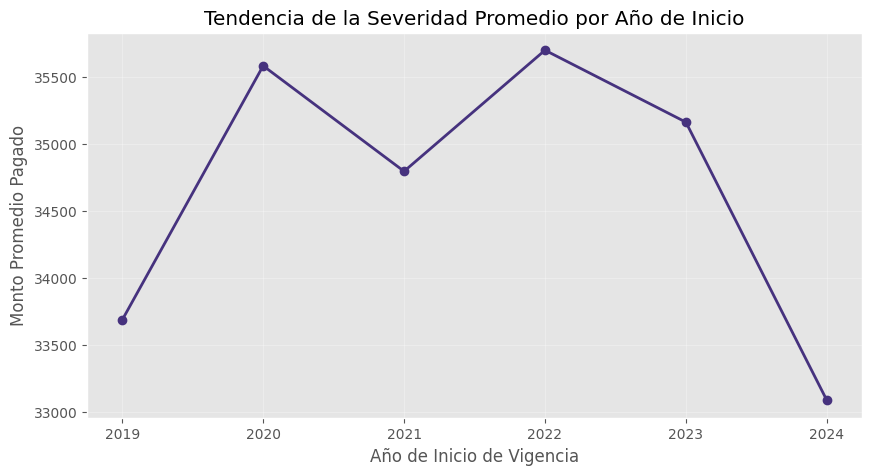

In [15]:

import warnings
warnings.filterwarnings('ignore')

# Filtramos solo las pólizas que tuvieron siniestros (monto_pagado > 0)
df_siniestrados = df_preproc[df_preproc['monto_pagado'] > 0].copy()

# Crear año de inicio de vigencia (si no existe)
df_preproc['año_inicio'] = pd.to_datetime(
    df_preproc['fecha_inicio_vigencia']
).dt.year

# Filtramos únicamente pólizas con siniestros pagados
df_siniestrados = df_preproc[df_preproc['monto_pagado'] > 0].copy()


# Media por Sexo
media_sexo = df_siniestrados.groupby('sexo')['monto_pagado'].mean()

print("Media del siniestro por Sexo:")
print(media_sexo.round(2))


# Media por Año de Inicio
media_anio = df_siniestrados.groupby('año_inicio')['monto_pagado'].mean()

print("\nMedia del siniestro por Año de Inicio de Vigencia:")
print(media_anio.round(2))


# Media por Plan
media_plan = (
    df_siniestrados
    .groupby('plan', observed=False)['monto_pagado']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

print("\nMedia del siniestro por Plan (Top 10):")
print(media_plan.head(10).round(2))


# Gráfica de tendencia por año
plt.figure(figsize=(10, 5))

media_anio.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title('Tendencia de la Severidad Promedio por Año de Inicio')
plt.xlabel('Año de Inicio de Vigencia')
plt.ylabel('Monto Promedio Pagado')
plt.grid(True, alpha=0.3)

plt.show()

Se calculó la severidad promedio (monto pagado promedio) de los siniestros considerando únicamente las pólizas con pagos registrados.

Por sexo, se observa que las mujeres presentan una severidad promedio de $35,543.28, mientras que los hombres registran una severidad promedio de $33,789.19. Esto indica que, en promedio, los siniestros de las mujeres fueron ligeramente más costosos que los de los hombres.

Por año de inicio de vigencia, la severidad promedio presenta variaciones moderadas entre los distintos años. El valor más alto se observa en 2022, con un monto promedio de $35,702.71, mientras que el más bajo corresponde a 2024, con $33,087.18. La gráfica muestra que no existe una tendencia creciente o decreciente claramente definida, sino fluctuaciones relativamente estables alrededor de los $34,000–$36,000.

Por plan, los mayores montos promedio se registran en los planes Individual ($36,931.70) y Plus ($35,980.02), mientras que los planes Premium ($33,581.00) y Básico ($33,949.71) presentan severidades promedio menores. Esto sugiere que algunos planes concentran reclamaciones de mayor costo que otros.